In [2]:
!pip install ydata-profiling

import pandas as pd
from ydata_profiling import ProfileReport

# 1. Cargamos el dataset
df_obesidad = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# 2. Generamos y exportamos el reporte
profile = ProfileReport(df_obesidad, title="Reporte de Obesidad Profiling")
profile.to_file("reporte_obesidad.html")

/home/yaco/Documentos/tp-ciencia-datos/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_6025/803835148.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
Summarize dataset:  77%|▊| 17/22 [00:00<00:00, 88.34it/s, Describe variable: NO
Export report to file: 100%|████████████████████| 1/1 [00:00<00:00, 117.98it/s]


Análisis de la distribución e histogramas frente a describe():
El método describe() que utilizamos en la clase anterior es excelente para obtener estadísticos de resumen (media, desvío estándar, valores mínimos, máximos y cuartiles). Sin embargo, no permite visualizar la forma de la distribución de los datos.
Al analizar los histogramas en el ProfileReport, podrás observar el comportamiento estadístico de cada variable de manera aislada (análisis univariado). Por ejemplo, podrías notar si la variable Age (Edad) tiene una distribución sesgada hacia la derecha (mayoría de personas jóvenes) o si el Weight (Peso) presenta múltiples picos (bimodal), algo que los simples números del describe() ocultan.  

b)
Basándonos en las columnas numéricas del conjunto de datos, podemos plantear las siguientes 3 hipótesis:  

Hipótesis 1 (Actividad Física vs. Peso): Existe una correlación lineal negativa entre la frecuencia de actividad física (FAF) y el peso (Weight). Es decir, a mayor actividad física, menor peso.

Hipótesis 2 (Edad vs. Peso): Existe una correlación lineal positiva entre la edad (Age) y el peso (Weight). Es decir, a medida que aumenta la edad de los individuos en este dataset, tiende a aumentar su peso.

Hipótesis 3 (Consumo de Agua vs. Peso): Existe una correlación lineal negativa entre el consumo diario de agua (CH2O) y el peso (Weight). A mayor consumo de agua, menor peso.

Correlacion y Scatter Plots

Para estudiar estas hipótesis, calcularemos el coeficiente de correlación de Pearson, el cual toma valores entre -1 y 1 e indica si existe una asociación lineal (positiva o negativa) entre las variables. Además, utilizaremos gráficos de dispersión (scatter plots) para entender la forma en la que los puntos se distribuyen en el espacio.  

Correlación entre FAF y Weight: -0.0514


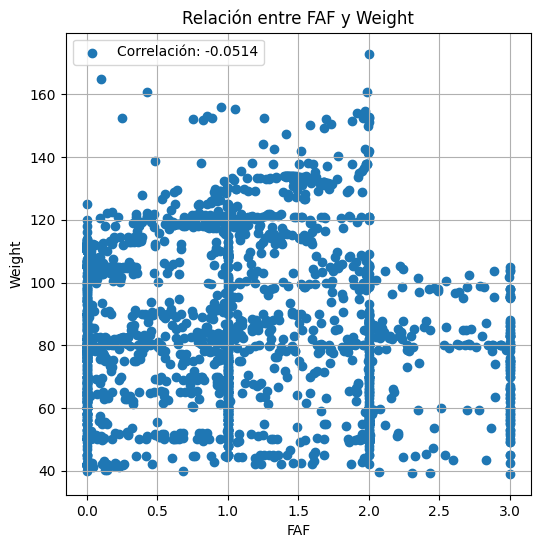

Correlación entre Age y Weight: 0.2026


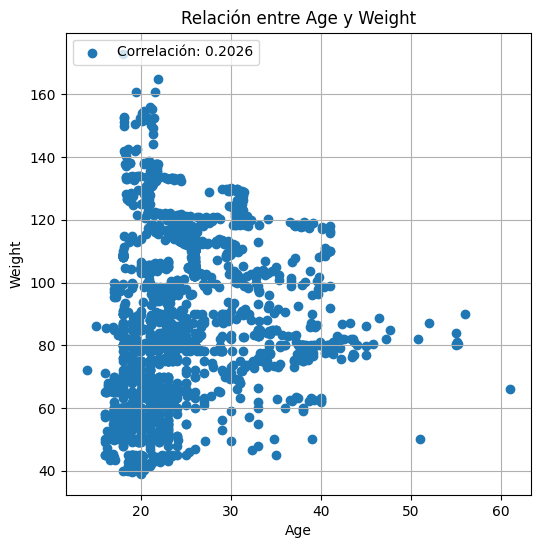

Correlación entre CH2O y Weight: 0.2006


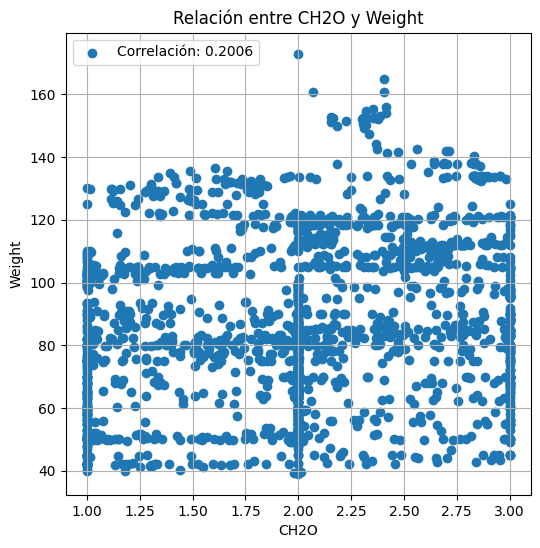

In [3]:
#Para mostrar los graficos en linea
%matplotlib inline


import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def analizar_hipotesis(variable_1, variable_2, dataframe):
    # Extraer las columnas del DataFrame
    datos_columna1 = dataframe[variable_1]
    datos_columna2 = dataframe[variable_2]
    
    # Calcular la correlación de Pearson usando SciPy
    coeficiente_correlacion, _ = stats.pearsonr(datos_columna1, datos_columna2)
    print(f"Correlación entre {variable_1} y {variable_2}: {coeficiente_correlacion:.4f}")
    
    # Creamos el scatter plot
    plt.figure(figsize=(6, 6))
    plt.scatter(datos_columna1, datos_columna2)
    plt.xlabel(variable_1)
    plt.ylabel(variable_2)
    plt.title("Relación entre {} y {}".format(variable_1, variable_2))
    
    # Agregar la leyenda con el valor del coeficiente de correlación
    plt.legend([f"Correlación: {coeficiente_correlacion:.4f}"], loc="upper left")
    
    plt.grid(True)
    plt.show()

analizar_hipotesis("FAF", "Weight", df_obesidad)

analizar_hipotesis("Age", "Weight", df_obesidad)

analizar_hipotesis("CH2O", "Weight", df_obesidad)

Si la correlación de Pearson da por encima de 0.7 (o por debajo de -0.7), la relación entre esas dos variables es fuerte y merece análisis extra. Valores cercanos a 0 sugieren que no hay una correlación lineal evidente.

Hipótesis 1 (Actividad Física - FAF vs. Peso): r = -0.0514
Análisis: El valor es prácticamente cero.
Conclusión: La hipótesis no es verosímil en términos de relación lineal. No existe una correlación lineal evidente entre la frecuencia de actividad física y el peso en este conjunto de datos.

Hipótesis 2 (Edad vs. Peso): r = 0.2026
Análisis: Existe una correlación positiva, pero es muy débil (lejos del umbral de 0.7 mencionado en la teoría).
Conclusión: La hipótesis es parcialmente verosímil, ya que hay una leve tendencia al alza (a mayor edad, un ligero aumento de peso), pero la fuerza de esta relación es demasiado baja para ser determinante por sí sola.

Hipótesis 3 (Consumo de Agua - CH2O vs. Peso): r = 0.2006
Análisis: La hipótesis original planteaba una correlación negativa (a mayor agua, menor peso), pero el resultado arrojó una correlación positiva débil.
Conclusión: La hipótesis no es verosímil. Los datos muestran lo contrario a lo supuesto: quienes consumen más agua en este dataset tienden a tener un peso ligeramente mayor, aunque nuevamente, la relación es muy débil.

El coeficiente de Pearson solo evalúa relaciones lineales. El hecho de que estas correlaciones sean bajas no significa que las variables no interactúen, sino que la relación no se puede explicar con una simple línea recta, o bien que el peso está fuertemente influenciado por factores multivariados (una combinación de genética, comida calórica, etc.) que no se pueden capturar analizando las variables de a pares.

In [3]:
%matplotlib inline
import pandas as pd
from ydata_profiling import ProfileReport

# Agregamos encoding='latin-1' para evitar el error de lectura
df_netflix = pd.read_csv("netflix_titles.csv", encoding='latin-1')

profile_netflix = ProfileReport(df_netflix, title="Reporte de Netflix Profiling")
profile_netflix.to_file("reporte_netflix.html")

Summarize dataset:  42%|▍| 13/31 [00:00<00:01,  9.16it/s, Describe variable: Un
Summarize dataset:  77%|▊| 24/31 [00:01<00:00,  7.11it/s, Describe variable: Un
Export report to file: 100%|████████████████████| 1/1 [00:00<00:00, 134.80it/s]


Hipótesis 1 (Año de Lanzamiento vs. Duración de Películas): Existe una correlación lineal entre el año en que se lanzó una película (release_year) y su duración en minutos. Podríamos suponer que las películas más modernas tienden a ser más cortas.

Hipótesis 2 (Año de Lanzamiento vs. Año de adición a Netflix): Existe una correlación lineal positiva entre el año de lanzamiento (release_year) y el año en el que el contenido fue subido a la plataforma. Esto se debe a que Netflix estrena gran cantidad de contenido original el mismo año en que lo produce.

Hipótesis 3 (Año de Lanzamiento vs. Temporadas de Series): Existe una correlación lineal negativa entre el año de lanzamiento de una serie de TV y su cantidad de temporadas. Las series estrenadas hace más tiempo (años menores) tuvieron margen para producir más temporadas que los estrenos recientes.

Nota metodológica: Para poder calcular la correlación de Pearson, primero separamos y limpiamos los datos para extraer los valores numéricos de las duraciones (quitando "min" y "Seasons") y transformamos las fechas. Esto es un paso fundamental ya que la función stats.pearsonr exige variables numéricas.

Correlación entre release_year y duration_min: -0.2063


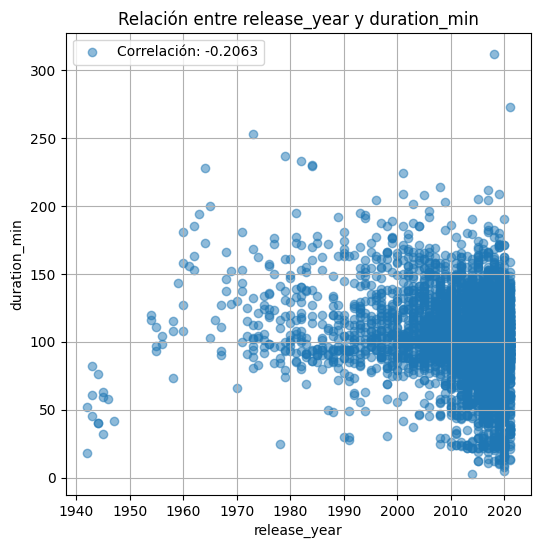

Correlación entre release_year y year_added: 0.0394


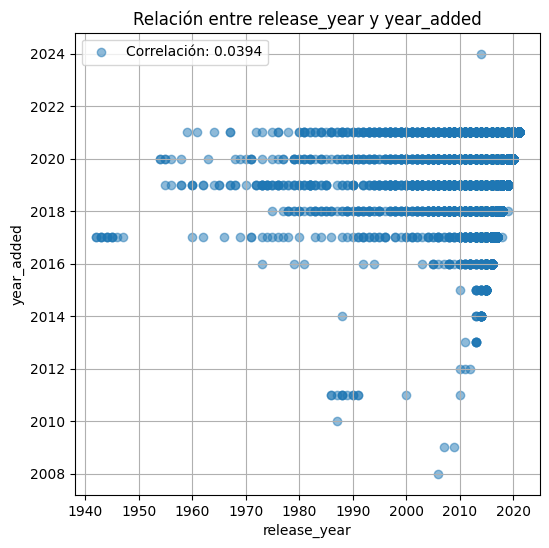

Correlación entre release_year y duration_seasons: -0.0904


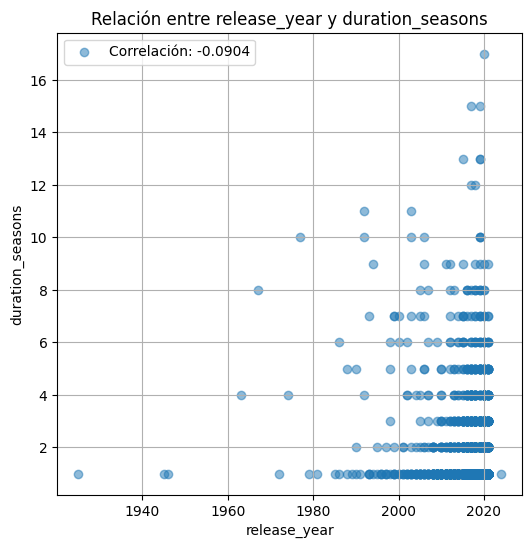

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Agregado
from scipy import stats

# Asumo que df_netflix ya está cargado previamente en tu Colab.
df_movies = df_netflix[df_netflix['type'] == 'Movie'].copy()
df_shows = df_netflix[df_netflix['type'] == 'TV Show'].copy()

# Pasamos a float (agregada la 'r' antes de la expresión regular para evitar warnings)
df_movies['duration_min'] = df_movies['duration'].astype(str).str.replace(' min', '').astype(float)
df_shows['duration_seasons'] = df_shows['duration'].astype(str).str.extract(r'(\d+)').astype(float)

df_movies['year_added'] = pd.to_datetime(df_movies['date_added'], errors='coerce').dt.year

# Limpiamos valores nulos de las columnas a analizar
df_movies_clean = df_movies.dropna(subset=['release_year', 'duration_min', 'year_added'])
df_shows_clean = df_shows.dropna(subset=['release_year', 'duration_seasons'])

def analizar_hipotesis(variable_1, variable_2, dataframe):
    datos_columna1 = dataframe[variable_1]
    datos_columna2 = dataframe[variable_2]

    # Nombre de variable corregido y unificado
    coef_correlacion, _ = stats.pearsonr(datos_columna1, datos_columna2)
    print(f"Correlación entre {variable_1} y {variable_2}: {coef_correlacion:.4f}")

    plt.figure(figsize=(6, 6))
    plt.scatter(datos_columna1, datos_columna2, alpha=0.5) 
    plt.xlabel(variable_1)
    plt.ylabel(variable_2)
    plt.title(f"Relación entre {variable_1} y {variable_2}")
    
    # Aquí llamamos a la misma variable que calculamos arriba
    plt.legend([f"Correlación: {coef_correlacion:.4f}"], loc="upper left")
    plt.grid(True)
    plt.show()
    plt.close() # Agregado para limpiar la memoria

# Ejecutamos las hipótesis
analizar_hipotesis("release_year", "duration_min", df_movies_clean)
analizar_hipotesis("release_year", "year_added", df_movies_clean)
analizar_hipotesis("release_year", "duration_seasons", df_shows_clean)

Resultado Hipótesis 1: r = -0.2063
Conclusión: La hipótesis no es verosímil. Aunque hay una ligerísima tendencia que indica que las películas más nuevas son un poco más cortas, la relación lineal es casi nula. El año de lanzamiento no determina la duración de una película, ya que el estándar de 90 a 120 minutos se ha mantenido constante durante décadas.

Resultado Hipótesis 2: r = 0.0394
Conclusión: La hipótesis no es verosímil. La plataforma compra y sube constantemente películas clásicas. Al agregarse películas de 1980 y de 2021 exactamente en el mismo año, la posible línea recta de correlación se rompe por completo.

Resultado Hipótesis 3: r = -0.0904
Conclusión: La hipótesis no es verosímil estadísticamente. Si bien cronológicamente las series más antiguas tuvieron más tiempo para sumar temporadas, la inmensa mayoría de las series en Netflix (antiguas o nuevas) terminan con 1 o 2 temporadas. Esto aplana los datos e impide una correlación fuerte.

In [5]:
import pandas as pd
from ydata_profiling import ProfileReport

# Cargar el archivo Excel especificando la hoja si es necesario
xls = pd.ExcelFile("catalogo_streaming_argentina_2024.xlsx")
df_streaming = pd.read_excel(xls, sheet_name=xls.sheet_names[0])

# Generar y exportar el reporte
profile = ProfileReport(df_streaming, title="Catálogo Streaming 2024")
profile.to_file("reporte_streaming.html")

Summarize dataset:  24%|▏| 4/17 [00:00<00:00, 16.89it/s, Describe variable: url
Summarize dataset:  59%|▌| 10/17 [00:00<00:00, 15.32it/s, Describe variable: ur
Export report to file: 100%|████████████████████| 1/1 [00:00<00:00, 319.23it/s]


Planteo de Hipótesis Bivariadas

Crítica vs. Crítica (imdbScore vs. tmdbScore): Existe una correlación lineal positiva fuerte. Si una película es bien valorada en IMDb, el público de TMDB tenderá a darle también un puntaje alto.

Popularidad vs. Calidad (imdbVotes vs. imdbScore): Existe una correlación lineal positiva. Los títulos con puntajes más altos atraen a una mayor cantidad de usuarios que dejan su voto.

Duración vs. Puntaje (runtime vs. imdbScore): Existe una correlación lineal positiva leve en las películas. Las obras más largas (dramas épicos, documentales) tienden a recibir mejores puntajes que los cortometrajes o títulos de duración promedio.

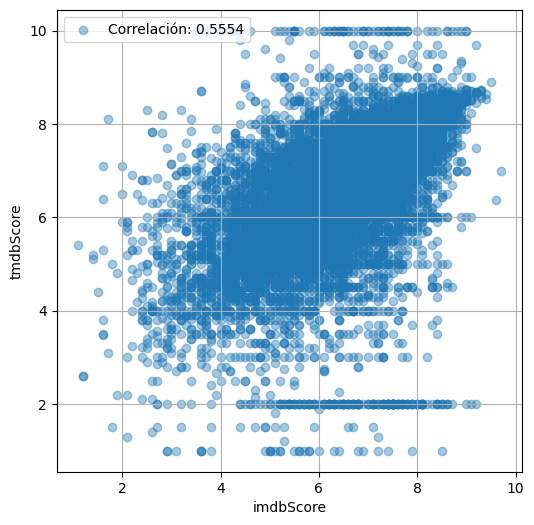

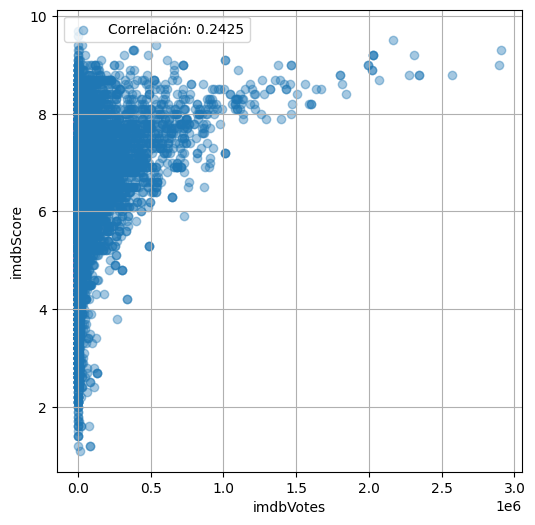

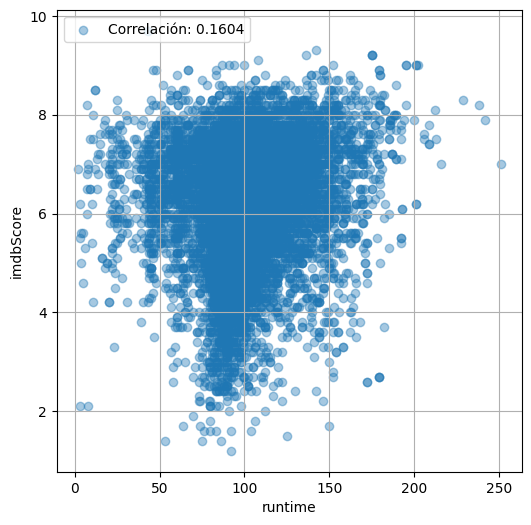

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats

def analizar_hipotesis(var1, var2, df_filtrado):
    r, _ = stats.pearsonr(df_filtrado[var1], df_filtrado[var2])
    
    plt.figure(figsize=(6, 6))
    plt.scatter(df_filtrado[var1], df_filtrado[var2], alpha=0.4)
    plt.xlabel(var1)
    plt.ylabel(var2)
    plt.legend([f"Correlación: {r:.4f}"], loc="upper left")
    plt.grid(True)
    plt.show()
    plt.close()

# 1. Limpieza de nulos
df_clean1 = df_streaming.dropna(subset=['imdbScore', 'tmdbScore'])
df_clean2 = df_streaming.dropna(subset=['imdbVotes', 'imdbScore'])
df_movies = df_streaming[df_streaming['type'] == 'MOVIE'].dropna(subset=['runtime', 'imdbScore'])

# 2. Análisis
analizar_hipotesis('imdbScore', 'tmdbScore', df_clean1)
analizar_hipotesis('imdbVotes', 'imdbScore', df_clean2)
analizar_hipotesis('runtime', 'imdbScore', df_movies)

Verosimilitud de los resultados:

Hipótesis 1 (r = 0.5554): Verosímil. Existe una correlación positiva moderada-fuerte. Ambas bases de datos reflejan el consenso general del público, por lo que los puntajes tienden a subir a la par.

Hipótesis 2 (r = 0.2425): Parcialmente verosímil. La correlación es débil. Si bien los clásicos bien puntuados reciben muchos votos, películas mediocres pero muy comerciales ("blockbusters") también acumulan millones de votos, rompiendo la linealidad.

Hipótesis 3 (r = 0.1604): Poco verosímil. Prácticamente no hay relación lineal. Un largometraje de 3 horas puede ser una obra de arte o un rotundo fracaso; la duración no garantiza el éxito crítico.